# 같은 loss, 다른 표현 — 손실 함수가 보지 않는 축

질문: **입력마다 다른 원-핫을 내는 '건강한' 경우의 loss는 붕괴한 경우와 어떻게 다른가?**

답: **똑같이 0이다.**

이 노트북은 asset 노트북 4절의 세 시나리오를 재현해 loss가 같음을 확인한 뒤,
**배치 축을 가로지르는 지표**를 추가로 계산해 두 상태가 확연히 갈리는 것을 보인다.

In [1]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_printoptions(precision=3, sci_mode=False)


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass

## 1. `MiniDINOLoss` — asset 노트북 3절과 동일

교차엔트로피 한 줄이 핵심이다.

$$\mathcal{L} = \frac{1}{B}\sum_{b=1}^{B} \Big( -\sum_{k=1}^{K} q_{bk}\,\log p_{bk} \Big)$$

안쪽 합은 **차원 축 $k$**, 바깥 평균은 **배치 축 $b$**.
즉 샘플 $b$의 loss는 다른 샘플 $b'$의 출력을 **한 번도 참조하지 않는다.**
이것이 loss가 붕괴에 무감각한 구조적 이유다.

In [2]:
class MiniDINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops=2, teacher_temp=0.04, student_temp=0.1,
                 center_momentum=0.9, use_center=True):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.use_center = use_center
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_output, teacher_output, return_per_sample=False):
        student_out = (student_output / self.student_temp).chunk(self.ncrops)
        center = self.center if self.use_center else 0.0
        teacher_out = F.softmax((teacher_output - center) / self.teacher_temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)

        total_loss, n_terms, per_sample = 0.0, 0, None
        for iq, q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v == iq:
                    continue
                # ★ dim=-1 : 차원 축만 합친다. 배치 축은 그대로 살아 있다.
                loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
                if per_sample is None:
                    per_sample = loss.detach().clone()
                total_loss += loss.mean()   # ★ 여기서 비로소 배치 축을 '평균'으로 뭉갠다
                n_terms += 1
        total_loss /= n_terms
        self.update_center(teacher_output)
        return (total_loss, per_sample) if return_per_sample else total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)

## 2. 세 가지 상수 출력 시나리오

| 시나리오 | 로짓 |
|---|---|
| 원-핫 붕괴 | 모든 샘플이 **같은** 차원 2에 50.0 |
| 균등 붕괴 | 모든 샘플이 전부 0 |
| 건강 | 샘플 $b$가 차원 $b \bmod K$에 50.0 (`F.one_hot(torch.arange(B) % out_dim, out_dim) * 50.0`) |

In [3]:
B, out_dim = 16, 8

collapsed = torch.zeros(B, out_dim)
collapsed[:, 2] = 50.0

uniform_c = torch.zeros(B, out_dim)

healthy = F.one_hot(torch.arange(B) % out_dim, out_dim).float() * 50.0

print("collapsed[:4] =\n", collapsed[:4])
print("healthy[:4]   =\n", healthy[:4])

collapsed[:4] =
 tensor([[ 0.,  0., 50.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 50.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 50.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 50.,  0.,  0.,  0.,  0.,  0.]])
healthy[:4]   =
 tensor([[50.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., 50.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., 50.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., 50.,  0.,  0.,  0.,  0.]])


In [4]:
def run(logits, name):
    loss_fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=0.04, use_center=False)
    both = torch.cat([logits, logits])          # crop 2개 모두 같은 출력
    total, per_sample = loss_fn(both, both, return_per_sample=True)
    print(f"{name:18s} loss = {total.item():.4f}   per-sample = {per_sample.numpy().round(4)[:8]} ...")
    return total.item(), per_sample


l_collapsed, ps_collapsed = run(collapsed, "one-hot collapse")
l_uniform, ps_uniform = run(uniform_c, "uniform collapse")
l_healthy, ps_healthy = run(healthy, "healthy one-hot")
print(f"\nlog K = {math.log(out_dim):.4f}")
print(f"one-hot collapse == healthy ?  {math.isclose(l_collapsed, l_healthy, abs_tol=1e-9)}")

one-hot collapse   loss = 0.0000   per-sample = [0. 0. 0. 0. 0. 0. 0. 0.] ...
uniform collapse   loss = 2.0794   per-sample = [2.0794 2.0794 2.0794 2.0794 2.0794 2.0794 2.0794 2.0794] ...
healthy one-hot    loss = 0.0000   per-sample = [0. 0. 0. 0. 0. 0. 0. 0.] ...

log K = 2.0794
one-hot collapse == healthy ?  True


**per-sample 벡터까지 완전히 같다.** 배치 평균을 취하기 *전*부터 이미 구분이 없다는 뜻이다.

샘플 $b$의 loss는 $-\sum_k q_{bk}\log p_{bk}$ — 여기에 등장하는 인덱스는 $b$ 하나뿐이다.
"샘플들끼리 서로 다른가"는 이 식에 **문법적으로 들어갈 자리가 없다**.

## 3. 배치 축을 보는 지표들

- $h_{\text{each}} = \frac{1}{B}\sum_b h(q_b)$ — "각 샘플이 확신하는가" (배치 축을 **평균**만 함 → 여전히 못 봄)
- $h_{\text{mean}} = h\!\left(\frac{1}{B}\sum_b q_b\right)$ — 먼저 **배치 축으로 평균한 분포**의 엔트로피 → 봄
- `top_share` = 가장 많이 쓰인 코드가 차지하는 샘플 비율
- `rank` = 확률 행렬 $Q \in \mathbb{R}^{B\times K}$의 수치적 랭크
- `mean_cos` = 서로 다른 샘플 쌍의 평균 코사인 유사도

In [5]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


@torch.no_grad()
def diagnostics(logits, teacher_temp=0.04):
    q = F.softmax(logits / teacher_temp, dim=-1)          # (B, K) teacher 분포
    h_each = entropy(q).mean().item() + 0.0               # 배치 축을 못 봄 (+0.0: -0.0 정리)
    h_mean = entropy(q.mean(0)).item() + 0.0              # 배치 축을 봄 ★
    codes = q.argmax(-1)
    top_share = codes.bincount(minlength=q.shape[-1]).max().item() / len(codes)
    rank = torch.linalg.matrix_rank(q, atol=1e-6).item()
    qn = F.normalize(q, dim=-1)
    sim = qn @ qn.T
    off = ~torch.eye(len(q), dtype=torch.bool)
    mean_cos = sim[off].mean().item()
    n_codes = len(codes.unique())
    return dict(h_each=h_each, h_mean=h_mean, top_share=top_share,
                rank=float(rank), mean_cos=mean_cos, n_codes=float(n_codes))


scenarios = [("one-hot collapse", collapsed, l_collapsed),
             ("uniform collapse", uniform_c, l_uniform),
             ("healthy one-hot", healthy, l_healthy)]

diags = {name: diagnostics(lg) for name, lg, _ in scenarios}

hdr = f"{'scenario':18s} {'loss':>7s} {'h_each':>7s} {'h_mean':>7s} {'top_share':>10s} {'rank':>5s} {'mean_cos':>9s} {'n_codes':>8s}"
print(hdr)
print("-" * len(hdr))
for name, _, ls in scenarios:
    d = diags[name]
    print(f"{name:18s} {ls:7.4f} {d['h_each']:7.4f} {d['h_mean']:7.4f} "
          f"{d['top_share']:10.4f} {d['rank']:5.0f} {d['mean_cos']:9.4f} {d['n_codes']:8.0f}")

scenario              loss  h_each  h_mean  top_share  rank  mean_cos  n_codes
------------------------------------------------------------------------------
one-hot collapse    0.0000  0.0000  0.0000     1.0000     1    1.0000        1
uniform collapse    2.0794  2.0794  2.0794     1.0000     1    1.0000        1
healthy one-hot     0.0000  0.0000  2.0794     0.1250     8    0.0667        8


핵심 두 줄은 **1행(원-핫 붕괴)과 3행(건강)**이다.

| 지표 | 붕괴 | 건강 | 구분되나 |
|---|---|---|---|
| `loss` | 0.0000 | 0.0000 | ❌ |
| `h_each` | 0.0000 | 0.0000 | ❌ (샘플별로 계산 후 평균 → 배치를 못 봄) |
| `h_mean` | 0.0000 | 2.0794 | ✅ (배치 평균 분포의 엔트로피) |
| `top_share` | 1.0000 | 0.1250 | ✅ |
| `rank` | 1 | 8 | ✅ |
| `mean_cos` | 1.0000 | 0.0667 | ✅ |

`h_each`가 loss와 함께 실패한다는 점이 중요하다.
**"먼저 샘플별로 계산하고 나중에 평균"하는 모든 양은 배치 축의 다양성을 볼 수 없다.**
`h_mean`처럼 **먼저 배치로 평균한 뒤 계산**해야 비로소 보인다. 순서가 전부다.

## 4. 어떤 손실이라면 이걸 볼 수 있는가

배치 축을 가로지르는 항이 있어야 한다.

In [6]:
qc = F.softmax(collapsed / 0.04, -1)
qh = F.softmax(healthy / 0.04, -1)


def infonce(q, tau=0.1):
    """자기 자신을 positive, 배치 내 나머지를 negative로 두는 대조 손실."""
    z = F.normalize(q, dim=-1)
    logits = z @ z.T / tau
    # positive = 자기 자신(같은 이미지의 다른 view라고 가정)
    return F.cross_entropy(logits, torch.arange(len(z))).item()


def barlow(q):
    """배치 축으로 표준화한 뒤 cross-correlation 행렬 C를 본다.
    붕괴를 잡는 것은 **대각 항** sum_i (1 - C_ii)^2 이다 (배치 분산이 죽으면 C_ii=0)."""
    zz = (q - q.mean(0)) / q.std(0).clamp_min(1e-6)
    c = zz.T @ zz / len(q)
    off = ~torch.eye(len(c), dtype=torch.bool)
    diag_term = (1 - c.diagonal()).pow(2).mean().item()
    off_term = c[off].pow(2).mean().item()
    return diag_term, off_term


def vicreg_var(q):
    """배치 축 표준편차의 평균 — 붕괴하면 0."""
    return q.std(0).mean().item()


print(f"{'':18s} {'DINO CE':>9s} {'InfoNCE':>9s} {'VICReg var':>11s} {'Barlow diag':>12s} {'Barlow off':>11s}")
for name, q, ls in [("one-hot collapse", qc, l_collapsed), ("healthy one-hot", qh, l_healthy)]:
    bd, bo = barlow(q)
    print(f"{name:18s} {ls:9.4f} {infonce(q):9.4f} {vicreg_var(q):11.4f} {bd:12.4f} {bo:11.4f}")

                     DINO CE   InfoNCE  VICReg var  Barlow diag  Barlow off
one-hot collapse      0.0000    2.7726      0.0000       1.0000      0.0000
healthy one-hot       0.0000    0.6935      0.3416       0.0039      0.0179


| 손실/장치 | 배치를 보는 방식 |
|---|---|
| InfoNCE | 분모의 **negative pair** — 다른 샘플과 가까우면 벌점 |
| Barlow Twins | 배치 축으로 표준화한 **cross-correlation 행렬**의 비대각을 0으로 |
| VICReg | **variance term** — 배치 축 표준편차가 임계값 아래면 벌점 |
| DINO | **centering** — 배치 평균을 EMA로 추적해 teacher 로짓에서 뺌 |

DINO만 이것이 손실 항이 아니라 **target 전처리**라는 점이 흥미롭다.
`q = softmax((teacher_logits - center) / temp)` — 배치 통계가 *정답지를 만드는 과정*에 들어간다.
손실 식 자체는 끝까지 샘플별 교차엔트로피 하나뿐이다.

그래서 위 표에서 보듯, DINO의 loss 값을 아무리 들여다봐도 붕괴는 보이지 않는다.
붕괴를 막는 힘은 loss 안이 아니라 **loss 바깥 (target 파이프라인)** 에 있다.

## 5. 시각화 — 같은 loss, 다른 표현

위: 두 출력의 배치×차원 확률 히트맵. 아래 왼쪽: loss 막대(둘 다 0). 아래 오른쪽: 진단 지표 막대.

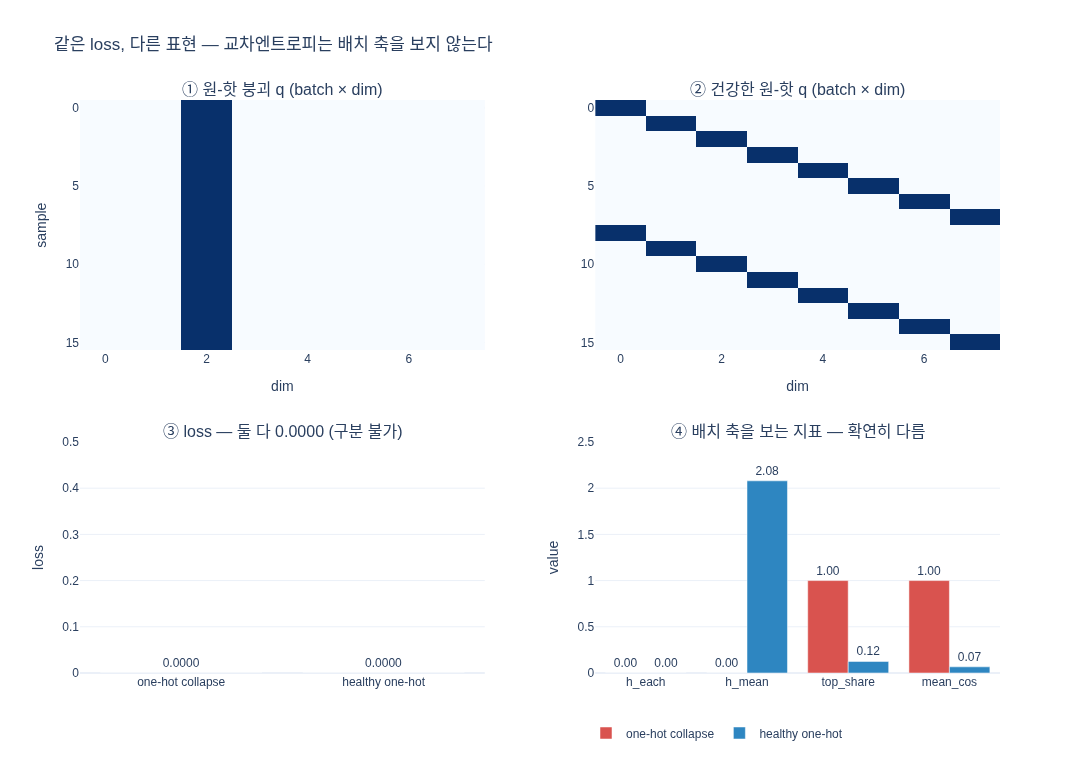

saved expy.png


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "① 원-핫 붕괴 q (batch × dim)",
        "② 건강한 원-핫 q (batch × dim)",
        "③ loss — 둘 다 0.0000 (구분 불가)",
        "④ 배치 축을 보는 지표 — 확연히 다름",
    ),
    vertical_spacing=0.16, horizontal_spacing=0.12,
    row_heights=[0.52, 0.48],
)

COL_BAD, COL_GOOD = "#D9534F", "#2E86C1"

fig.add_trace(go.Heatmap(z=qc.numpy(), colorscale="Blues", zmin=0, zmax=1,
                         showscale=False, hovertemplate="sample %{y}, dim %{x}: %{z:.2f}<extra></extra>"),
              row=1, col=1)
fig.add_trace(go.Heatmap(z=qh.numpy(), colorscale="Blues", zmin=0, zmax=1,
                         showscale=False, hovertemplate="sample %{y}, dim %{x}: %{z:.2f}<extra></extra>"),
              row=1, col=2)

fig.add_trace(go.Bar(x=["one-hot collapse", "healthy one-hot"],
                     y=[l_collapsed, l_healthy],
                     marker_color=[COL_BAD, COL_GOOD],
                     text=[f"{l_collapsed:.4f}", f"{l_healthy:.4f}"],
                     textposition="outside", showlegend=False),
              row=2, col=1)

metrics = ["h_each", "h_mean", "top_share", "mean_cos"]
dc, dh = diags["one-hot collapse"], diags["healthy one-hot"]
fig.add_trace(go.Bar(x=metrics, y=[dc[m] for m in metrics], name="one-hot collapse",
                     marker_color=COL_BAD,
                     text=[f"{dc[m]:.2f}" for m in metrics], textposition="outside"),
              row=2, col=2)
fig.add_trace(go.Bar(x=metrics, y=[dh[m] for m in metrics], name="healthy one-hot",
                     marker_color=COL_GOOD,
                     text=[f"{dh[m]:.2f}" for m in metrics], textposition="outside"),
              row=2, col=2)

fig.update_yaxes(title_text="sample", autorange="reversed", row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=2)
fig.update_xaxes(title_text="dim", row=1, col=1)
fig.update_xaxes(title_text="dim", row=1, col=2)
fig.update_yaxes(title_text="loss", range=[0, 0.5], row=2, col=1)
fig.update_yaxes(title_text="value", range=[0, 2.5], row=2, col=2)
fig.update_layout(
    title="같은 loss, 다른 표현 — 교차엔트로피는 배치 축을 보지 않는다",
    height=760, width=1080, barmode="group", template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.13, x=0.55),
)

fig.write_image("/home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/"
                "e746c8fb-c0c5-472d-b988-b210975b7909/expy.png", scale=2)
_show(fig)
print("saved expy.png")

## 6. 정리

1. 건강한 출력과 원-핫 붕괴 출력의 DINO loss는 **완전히 같은 0**이다. per-sample 값까지 같다.
2. 이유는 구조적이다 — 교차엔트로피는 각 샘플에 대해 독립으로 계산되고 나중에 평균된다.
   "샘플들끼리 서로 다른가"는 식에 등장하지 않는다.
3. `h_each`도 같은 이유로 실패한다. **배치로 먼저 평균한 뒤 계산**하는 `h_mean`,
   또는 `top_share` / `rank` / `mean_cos` 같은 배치 통계라야 구분된다.
4. 실전에서는 loss 곡선만 보면 안 된다. teacher 출력의 `h_each`/`h_mean` 짝,
   코드 사용 히스토그램, 그리고 주기적인 k-NN 정확도를 함께 로깅해야 붕괴를 조기 감지한다.